###Import Libraries

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold, LeaveOneOut, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

###Upload Dataset

In [77]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_prediction_dataset.csv to customer_churn_prediction_dataset (2).csv


###Read Dataset

In [78]:
df = pd.read_csv("customer_churn_prediction_dataset.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0296-XXXX,Female,1,No,Yes,61,No,Yes,DSL,No,...,Yes,No internet service,No,No,One year,Yes,Electronic check,42.52,2593.72,No
296,0297-XXXX,Female,0,No,No,49,Yes,No phone service,DSL,No internet service,...,Yes,No internet service,Yes,Yes,Month-to-month,Yes,Mailed check,22.31,1093.19,Yes
297,0298-XXXX,Male,0,No,Yes,71,Yes,Yes,DSL,No internet service,...,Yes,Yes,No,Yes,Two year,No,Mailed check,59.57,4229.47,Yes
298,0299-XXXX,Male,1,Yes,Yes,1,Yes,Yes,No,Yes,...,No internet service,No internet service,Yes,Yes,Two year,No,Credit card,31.32,31.32,No


#Exploration Data Analysist

###Data Type Information

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        300 non-null    object 
 1   gender            300 non-null    object 
 2   SeniorCitizen     300 non-null    int64  
 3   Partner           300 non-null    object 
 4   Dependents        300 non-null    object 
 5   tenure            300 non-null    int64  
 6   PhoneService      300 non-null    object 
 7   MultipleLines     300 non-null    object 
 8   InternetService   300 non-null    object 
 9   OnlineSecurity    300 non-null    object 
 10  OnlineBackup      300 non-null    object 
 11  DeviceProtection  300 non-null    object 
 12  TechSupport       300 non-null    object 
 13  StreamingTV       300 non-null    object 
 14  StreamingMovies   300 non-null    object 
 15  Contract          300 non-null    object 
 16  PaperlessBilling  300 non-null    object 
 1

###Descriptive Statistics

In [46]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,300.000000,300.000000,300.000000,300.000000
mean,0.543333,35.783333,67.226800,2477.975767
std,0.498951,21.113400,28.638073,1918.540111
min,0.000000,1.000000,18.450000,30.030000
25%,0.000000,17.000000,42.337500,910.302500
50%,1.000000,36.000000,68.635000,2072.400000
75%,1.000000,53.250000,92.430000,3618.405000
max,1.000000,72.000000,118.640000,8318.880000


###Checking Unique Value

In [80]:
cat_features = df.select_dtypes(include=['object']).columns
unique_counts = df[cat_features].nunique().reset_index()
unique_counts.columns = ['Categorical Feature', 'Unique Values Count']
unique_counts

,Categorical Feature,Unique Values Count
0,customerID,300
1,gender,2
2,Partner,2
3,Dependents,2
4,PhoneService,2
5,MultipleLines,3
6,InternetService,3
7,OnlineSecurity,3
8,OnlineBackup,3
9,DeviceProtection,3


#Pre Processing

##Basic Pre Processing

###Drop Columns

In [81]:
df = df.drop(columns=['customerID', 'TotalCharges'])
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Male,0,Yes,Yes,5,No,Yes,No,No,Yes,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,Yes
1,Female,0,No,No,42,Yes,No phone service,DSL,Yes,Yes,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,Yes
2,Male,0,No,No,61,Yes,No phone service,No,No,Yes,No,Yes,Yes,No,One year,No,Bank transfer,106.44,Yes
3,Male,1,No,Yes,22,Yes,No,No,No internet service,No internet service,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,No
4,Male,1,Yes,Yes,21,No,No,DSL,No,No,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Female,1,No,Yes,61,No,Yes,DSL,No,No internet service,Yes,No internet service,No,No,One year,Yes,Electronic check,42.52,No
296,Female,0,No,No,49,Yes,No phone service,DSL,No internet service,No,Yes,No internet service,Yes,Yes,Month-to-month,Yes,Mailed check,22.31,Yes
297,Male,0,No,Yes,71,Yes,Yes,DSL,No internet service,No,Yes,Yes,No,Yes,Two year,No,Mailed check,59.57,Yes
298,Male,1,Yes,Yes,1,Yes,Yes,No,Yes,No internet service,No internet service,No internet service,Yes,Yes,Two year,No,Credit card,31.32,No


###Checking Nan

In [82]:
nan_data_by_column = df.isna().sum()
nan_total_data = df.isna().sum().sum()

print("NaN data by column:")
print(nan_data_by_column)
print("\nTotal NaN data in DataFrame:", nan_total_data)

NaN data by column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Churn               0
dtype: int64

Total NaN data in DataFrame: 0


###Check Missing Value

In [83]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Churn               0
dtype: int64


###Label Encoding

In [84]:
df_encoded = df.copy()

label_encoders = {}
for col in df_encoded.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Male,0,Yes,Yes,5,No,Yes,No,No,Yes,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,Yes
1,Female,0,No,No,42,Yes,No phone service,DSL,Yes,Yes,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,Yes
2,Male,0,No,No,61,Yes,No phone service,No,No,Yes,No,Yes,Yes,No,One year,No,Bank transfer,106.44,Yes
3,Male,1,No,Yes,22,Yes,No,No,No internet service,No internet service,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,No
4,Male,1,Yes,Yes,21,No,No,DSL,No,No,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,Yes


### Checking the target column with plot

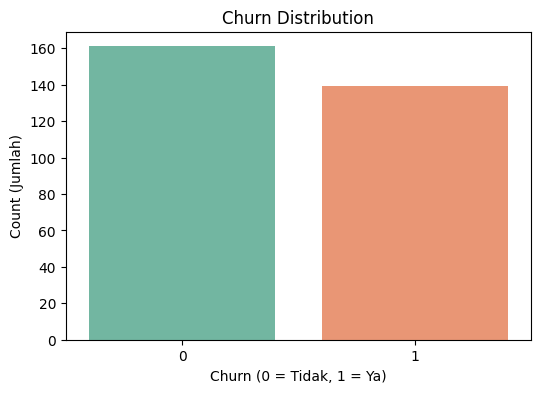

In [85]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df_encoded, palette="Set2")
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = Tidak, 1 = Ya)")
plt.ylabel("Count (Jumlah)")
plt.grid(False)
plt.show()

###Feature Correlation

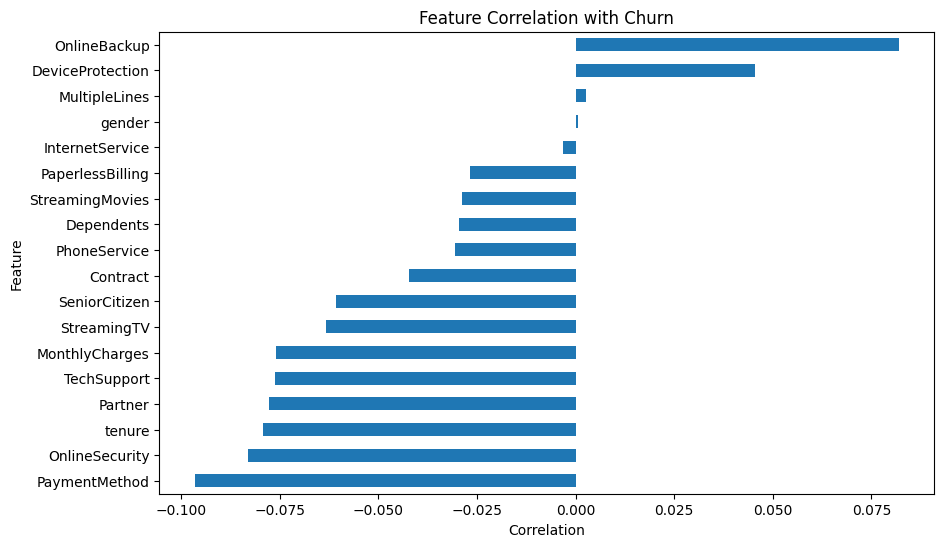

In [86]:
corr_with_target = df_encoded.corr()['Churn'].drop('Churn')

corr_with_target.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()

##Advance Preprocessing

### Split the data into features (X) and target (y)

In [87]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

###Split Data

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###Scale the Features

In [89]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Decision Model

###Build Model

In [19]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

###Prediksi Model

In [20]:
y_pred_dt = dt_model.predict(X_test_scaled)

###Hyperparameter Tuning

In [90]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10, 20],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.02]
}

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

grid_search_dt = GridSearchCV(dt, param_grid=param_grid_dt, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

print("\nBest Hyperparameters :")
print(grid_search_dt.best_params_)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits

Best Hyperparameters :
{'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}


###Evaluasi Model

In [91]:
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy :", acc_dt)
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.5333333333333333
              precision    recall  f1-score   support

           0       0.59      0.59      0.59        34
           1       0.46      0.46      0.46        26

    accuracy                           0.53        60
   macro avg       0.52      0.52      0.52        60
weighted avg       0.53      0.53      0.53        60



###Feature Importance

Ranking Fitur Paling Penting:
tenure              0.263368
MonthlyCharges      0.245955
DeviceProtection    0.067148
StreamingMovies     0.064263
TechSupport         0.057006
OnlineSecurity      0.055303
OnlineBackup        0.039672
PaymentMethod       0.037548
StreamingTV         0.032926
gender              0.030262
PhoneService        0.025085
Contract            0.023787
MultipleLines       0.019352
SeniorCitizen       0.017420
Dependents          0.012543
InternetService     0.008362
Partner             0.000000
PaperlessBilling    0.000000
dtype: float64


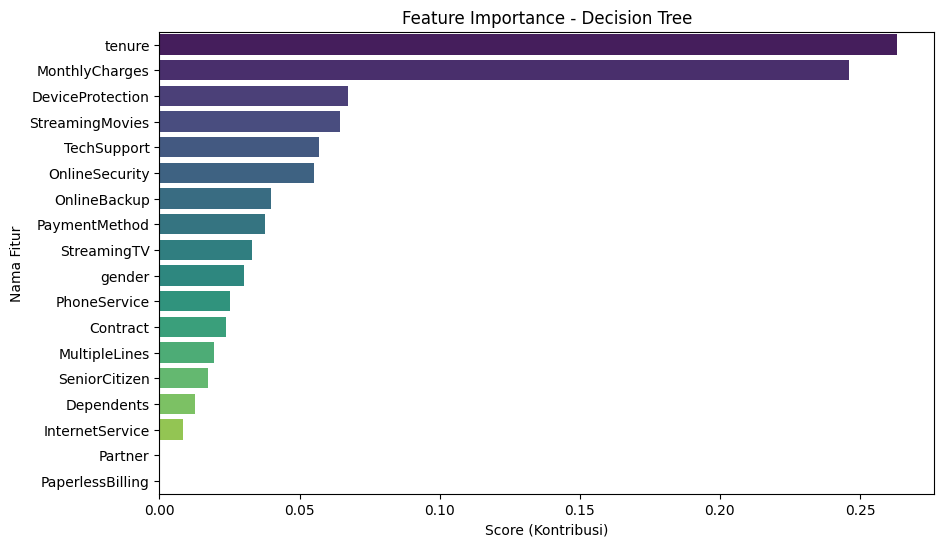

In [92]:
feature_imp = pd.Series(
    dt_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Ranking Fitur Paling Penting:")
print(feature_imp)

plt.figure(figsize=(10,6))

sns.barplot(
    x=feature_imp.values,
    y=feature_imp.index,
    palette='viridis'
)

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Score (Kontribusi)")
plt.ylabel("Nama Fitur")
plt.show()

###Visualization Decision Tree

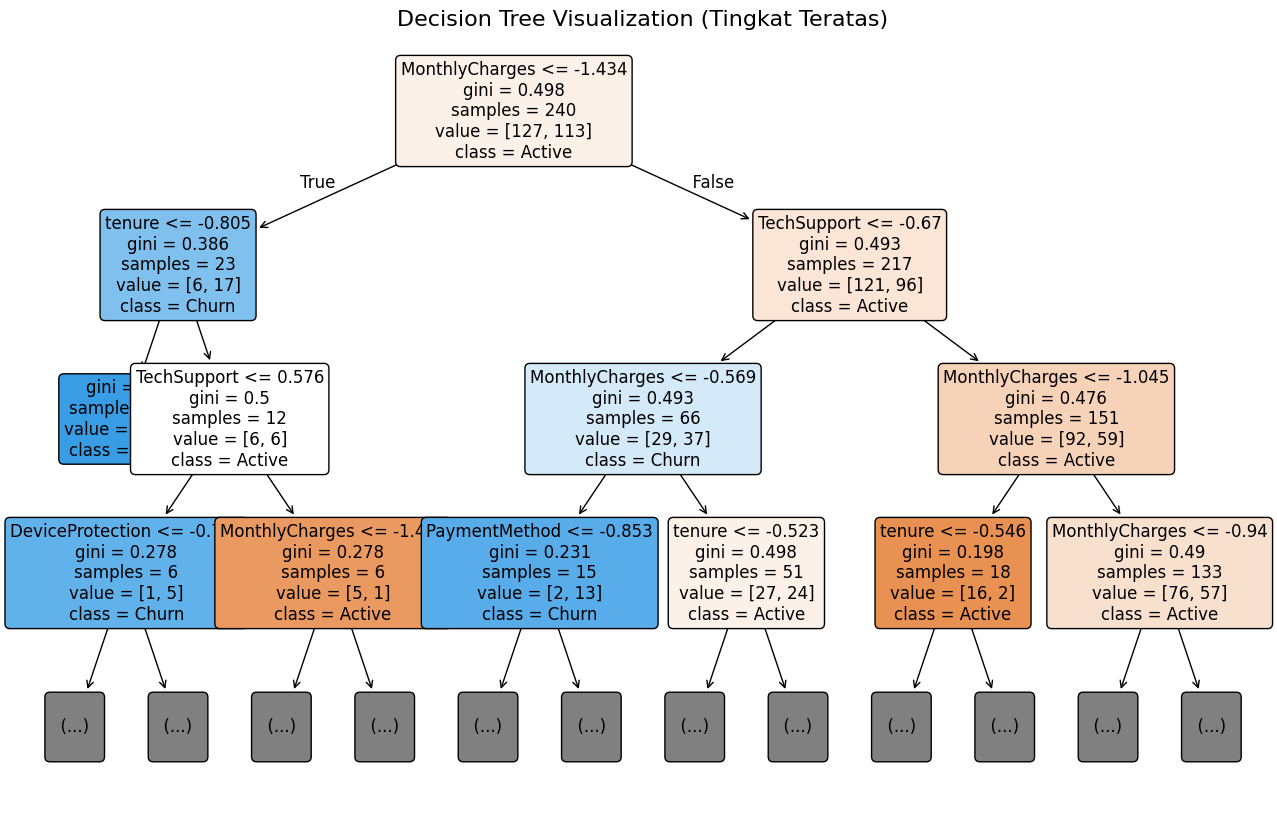

In [93]:
plt.figure(figsize=(16, 10))

plot_tree(
    dt_model,
    max_depth=3,
    feature_names=X.columns,
    class_names=['Active', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title('Decision Tree Visualization (Tingkat Teratas)', fontsize=16)
plt.show()

###Cross Validation 5-Vold

In [94]:
cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=5)
print(f"Cross-validation Accuracy (5-fold): {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")

Cross-validation Accuracy (5-fold): 0.52 (+/- 0.06)


###ROC Curve

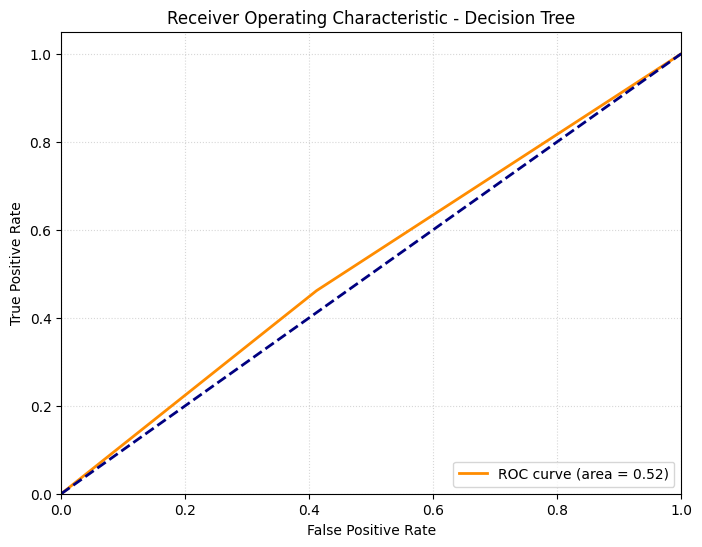

In [95]:
fpr, tpr, _ = roc_curve(y_test, y_pred_dt)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Decision Tree')
plt.legend(loc="lower right")
plt.grid(axis='both', linestyle=':', alpha=0.5)
plt.show()

###Confusion Matrix

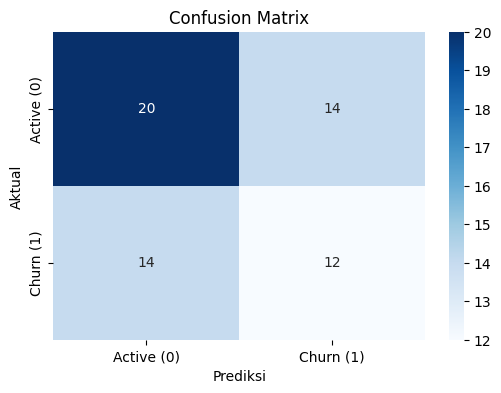

In [96]:
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Active (0)','Churn (1)'], yticklabels=['Active (0)','Churn (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

#Logistic Regression

###Build Model

In [97]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

###Prediksi Model

In [98]:
y_pred_lr = lr_model.predict(X_test_scaled)

###Evaluasi Model

In [99]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Akurasi Logistic Regression: {accuracy_lr:.2f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Akurasi Logistic Regression: 0.43

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.53      0.51        34
           1       0.33      0.31      0.32        26

    accuracy                           0.43        60
   macro avg       0.42      0.42      0.42        60
weighted avg       0.43      0.43      0.43        60



###Cross Validation 5-Fold

In [100]:
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=5)
print(f"Cross-validation Accuracy (5-fold): {cv_scores_lr.mean():.2f} (+/- {cv_scores_lr.std():.2f})")

Cross-validation Accuracy (5-fold): 0.57 (+/- 0.07)


###ROC-Curve

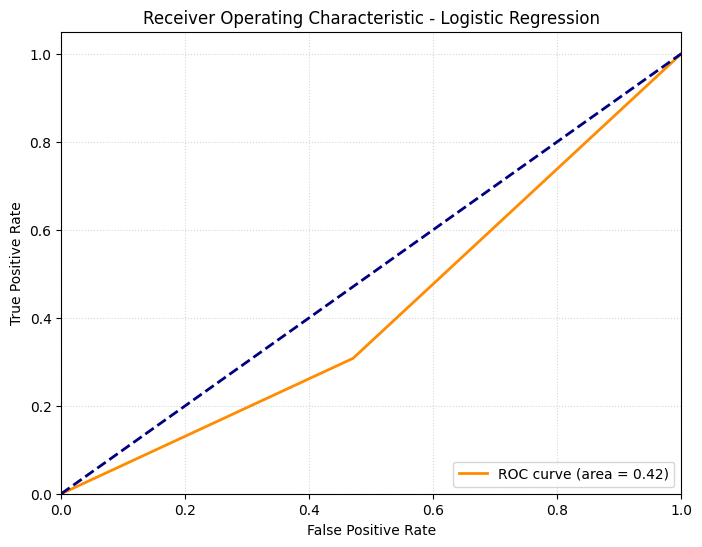

In [101]:
fpr, tpr, _ = roc_curve(y_test, y_pred_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(axis='both', linestyle=':', alpha=0.5)
plt.show()

###Feature Importance

Ranking Fitur Paling Penting:
Partner             0.324493
TechSupport         0.289895
tenure              0.269672
Contract            0.245583
PaymentMethod       0.231713
OnlineBackup        0.181420
MonthlyCharges      0.173356
DeviceProtection    0.164342
OnlineSecurity      0.127600
SeniorCitizen       0.120199
MultipleLines       0.090690
Dependents          0.079800
PaperlessBilling    0.053815
StreamingTV         0.050908
PhoneService        0.040316
gender              0.034195
StreamingMovies     0.032476
InternetService     0.015450
dtype: float64


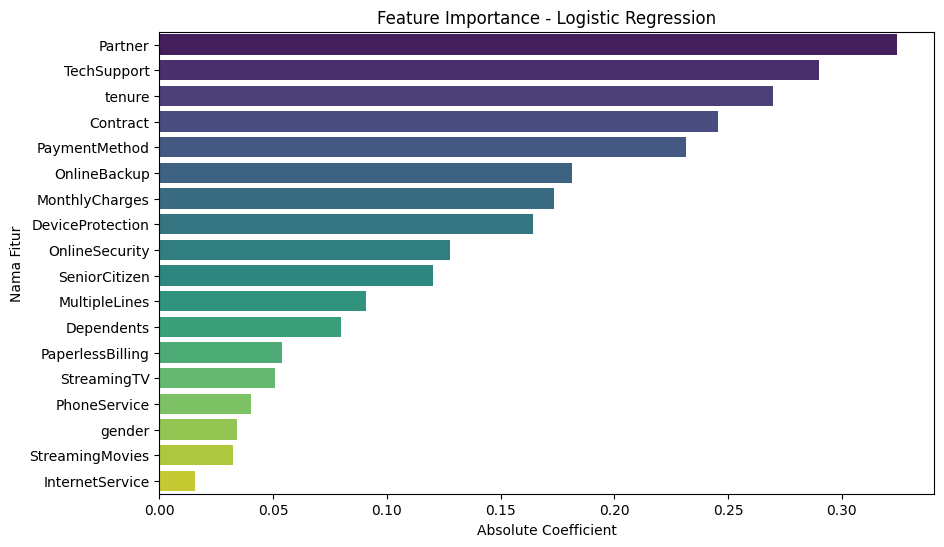

In [102]:
feature_imp = pd.Series(
    abs(lr_model.coef_[0]),
    index=X_train.columns
).sort_values(ascending=False)

print("Ranking Fitur Paling Penting:")
print(feature_imp)

plt.figure(figsize=(10,6))

sns.barplot(
    x=feature_imp.values,
    y=feature_imp.index,
    palette='viridis'
)

plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Nama Fitur")
plt.show()

###Confusion Matrix

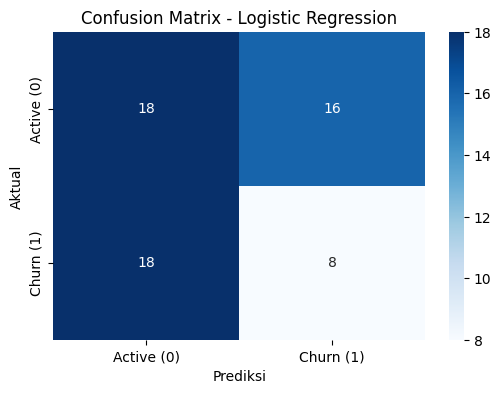

In [103]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Active (0)','Churn (1)'], yticklabels=['Active (0)','Churn (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

#ANN

###Build Model

In [104]:
ann_model = MLPClassifier(hidden_layer_sizes=(32,16), activation='relu', solver='adam', max_iter=500, random_state=42)
ann_model.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)

###Prediksi

In [105]:
y_pred_ann = ann_model.predict(X_test_scaled)

###Evaluasi Model

In [106]:
accuracy_ann = accuracy_score(y_test, y_pred_ann)
print(f"Akurasi ANN: {accuracy_ann:.2f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_ann))

Akurasi ANN: 0.45

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.50      0.51        34
           1       0.37      0.38      0.38        26

    accuracy                           0.45        60
   macro avg       0.44      0.44      0.44        60
weighted avg       0.45      0.45      0.45        60



###Cross Validatioon 5-Fold

In [107]:
cv_scores_ann = cross_val_score(ann_model, X_train_scaled, y_train, cv=5)
print(f"Cross-validation Accuracy (5-fold): {cv_scores_ann.mean():.2f} (+/- {cv_scores_ann.std():.2f})")

Cross-validation Accuracy (5-fold): 0.53 (+/- 0.13)


###ROC-Curve

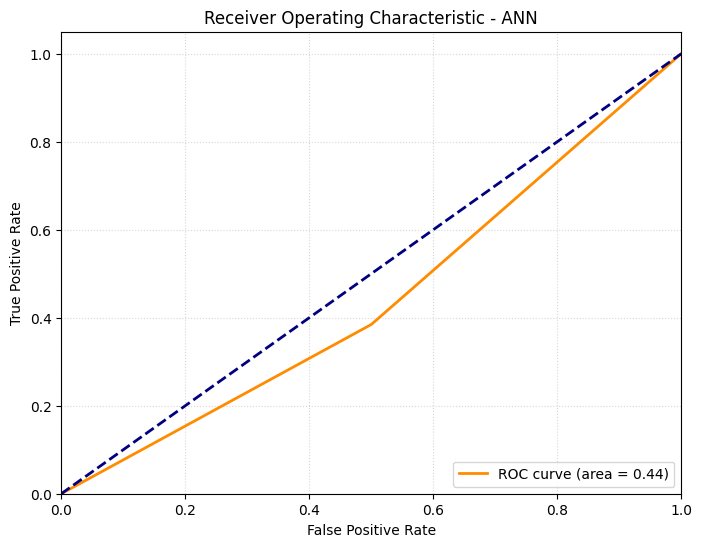

In [108]:
fpr, tpr, _ = roc_curve(y_test, y_pred_ann)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - ANN')
plt.legend(loc="lower right")
plt.grid(axis='both', linestyle=':', alpha=0.5)
plt.show()

###Feature Importance

Ranking Fitur Paling Penting:
Dependents          0.306899
InternetService     0.306841
PaymentMethod       0.304362
tenure              0.298217
TechSupport         0.294154
Partner             0.288970
Contract            0.279770
SeniorCitizen       0.265976
OnlineSecurity      0.263894
MonthlyCharges      0.256948
OnlineBackup        0.252587
PaperlessBilling    0.252395
StreamingMovies     0.250003
gender              0.247035
PhoneService        0.246538
DeviceProtection    0.242279
MultipleLines       0.241991
StreamingTV         0.221449
dtype: float64


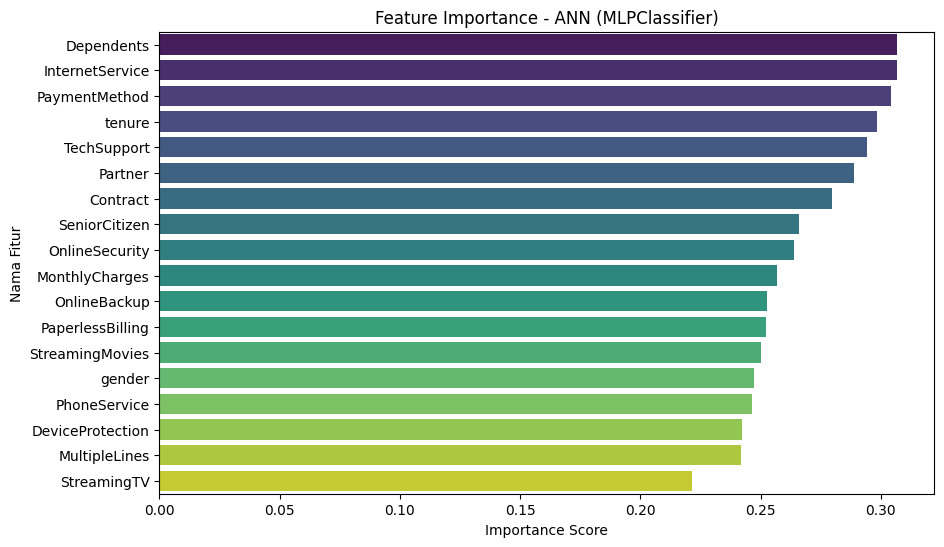

In [109]:
weights = np.abs(ann_model.coefs_[0])

feature_imp = pd.Series(
    weights.mean(axis=1),
    index=X_train.columns
).sort_values(ascending=False)

print("Ranking Fitur Paling Penting:")
print(feature_imp)

plt.figure(figsize=(10,6))

sns.barplot(
    x=feature_imp.values,
    y=feature_imp.index,
    palette='viridis'
)

plt.title("Feature Importance - ANN (MLPClassifier)")
plt.xlabel("Importance Score")
plt.ylabel("Nama Fitur")
plt.show()

###Confusion Matrix

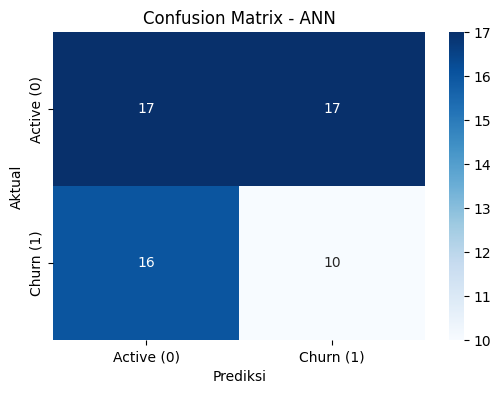

In [110]:
cm_ann = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(6,4))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', xticklabels=['Active (0)','Churn (1)'], yticklabels=['Active (0)','Churn (1)'])
plt.title('Confusion Matrix - ANN')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()